In [4]:
'''
In this file, we will attempt iterated approximate dynamic programming for the Zermelo problem.
Practically, this will just add an outer loop of length I to the ADP code.

In terms of what we save to visualise:

- The loss at each iteration
- The models resulting from each pass through T - 1 to 0

It may be interesting to visualise out-of-sample behaviour too. Ideally, we will see overlearning increase
'''

'\nIn this file, we will attempt iterated approximate dynamic programming for the Zermelo problem.\nPractically, this will just add an outer loop of length I to the ADP code.\n\nIn terms of what we save to visualise:\n\n- The loss at each iteration\n- The models resulting from each pass through T - 1 to 0\n\nIt may be interesting to visualise out-of-sample behaviour too. Ideally, we will see overlearning increase\n'

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import math
import pickle
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib import animation
from matplotlib.collections import LineCollection
import matplotlib.patches as mpatches
import time
import os

In [2]:
# Device setup
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
torch.set_default_dtype(torch.float32)
print("Running on:", device)

Running on: mps


In [3]:
def wind_process(T, theta, mu, wind_sigma, n, tau):
    num_to_sim = int(T / tau)
    winds = torch.zeros(n, num_to_sim + 1, device = device)
    winds[:, 0] = 0.5 * torch.rand(n , device = device) - 0.25 
    for step in range(1, num_to_sim + 1):
        dW = torch.randn(n , device = device)
        winds[:, step] = winds[:, step - 1] +(mu - winds[:, step - 1]) * theta * tau + wind_sigma * torch.sqrt(tau) * dW
    # only return winds for the integer time-steps
    final_wind = winds[:, 1:][:, ::int(1 / tau)]
    # add initial wind to the front
    winds = torch.cat((winds[:, 0].view(n, 1), final_wind), dim = 1)
    return winds

In [5]:
def running_cost(x, y, A, M):
    return( 1 - 1/(1 + torch.exp(A * (1 - x**2 - y**2)))) * M

def terminal_cost(x, y, L_x):
    return torch.norm(x - L_x, dim = 1, keepdim = True)**2 + torch.norm(y, dim = 1, keepdim = True)**2

def regularising(th1, th2, p, r):
    full_th = torch.cat((th1, th2))
    nrm = torch.norm(full_th)
    return nrm**p + 1e-9 * torch.exp(nrm)

def regularising_t(theta1, theta2, p, beta):
    theta_vmap = torch.vmap(regularising, in_dims=(0, 1, None, None))
    ells_by_j = theta_vmap(theta1, theta2, p, theta1.shape[0])
    return torch.sum(ells_by_j) / (2 * beta**2)

def gen_ref_path(reference_control, p0, winds, vs, T, n):
    ref_path = torch.zeros(n, T+1, 2, device = device) # use a 3D tensor to store path information
    ref_path[:, 0, :] = p0 
    for t in range(T): 
        heading = torch.cat([torch.cos(reference_control), torch.sin(reference_control)], dim = 1)
        wind_vec = torch.cat([torch.zeros(n, device = device).view(n, 1), winds[:, t].view(n, 1)], dim = 1)
        ref_path[:, t+1, :] = ref_path[:, t] + vs * heading + wind_vec
    return ref_path

In [6]:
class NeuralNet_erm(nn.Module):
    def __init__(self, input_dim, width, output_dim):
        super(NeuralNet_erm, self).__init__()
        self.hidden_layer = nn.Linear(input_dim, width)
        self.hidden_layer_2 = nn.Linear(width, width)
        self.hidden_layer_3 = nn.Linear(width, width)
        self.hidden_layer_4 = nn.Linear(width, width)
        self.sigmoid = nn.Tanh()
        self.output_layer = nn.Linear(width, output_dim)
        
    def forward(self, x):
        activations_1 = self.sigmoid(self.hidden_layer(x))
        activations_2 = self.sigmoid(self.hidden_layer_2(activations_1))
        activations_3 = self.sigmoid(self.hidden_layer_3(activations_2))
        activations_4 = self.sigmoid(self.hidden_layer_4(activations_3))
        unscaled = self.output_layer(activations_4)
        return unscaled


In [44]:
# Some hyperparameters

n = 64
T = 20
L_x = 10
theta = 0.1
mu = 0
wind_sigma = 0.05
tau = torch.tensor(1, device = device)
A = 2 # controls how soft/hard the obstacle cost is
M = 10 # controls how high the cost is
vs = 1 # speed of boat
I = 10 # number of outer loops


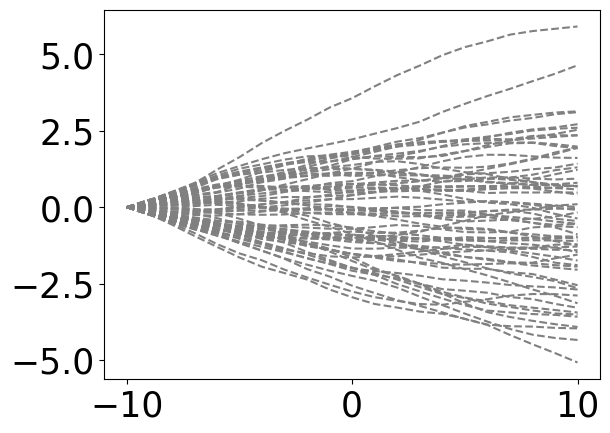

In [45]:
# generate reference trajectories
ref_ctrl = torch.zeros(n, 1, device = device)
initial_points = torch.zeros(n, 2, device = device) - torch.tensor([10, 0], device = device)
training_winds = wind_process(T, theta, mu, wind_sigma, n, tau)
ref_path = gen_ref_path(ref_ctrl, initial_points, training_winds, vs, T, n)

for r in range(n):
    plt.plot(ref_path[r, :, 0].cpu(), ref_path[r, :, 1].cpu(), color = "gray", linestyle = "--")

In [47]:
# training loop 
zeros_vec, ones_vec = torch.zeros(n, 1, device = device), torch.ones(n, 1, device = device) # just for later
ref_ctrl = torch.zeros(n, 1, device = device)
initial_points = torch.zeros(n, 2, device = device) - torch.tensor([10, 0], device = device)
# empirical risk minimisation
input_dim, width, output_dim = 3, 200, 1
start_rate, final_rate, num_epochs = 0.00001, 0.000000001, 1000
models_erm = [NeuralNet_erm(input_dim, width, output_dim).to(device) for _ in range(T)]
optimisers = [optim.AdamW(model.parameters(), lr=start_rate) for model in models_erm]
schedulers = [optim.lr_scheduler.CosineAnnealingLR(opt, T_max = num_epochs, eta_min = final_rate) for opt in optimisers]
losses_per_i = []

latest_ref_path = ref_path
for i in range(I): # iteration outer loop
    print(f"I = {i + 1}")
    losses = []
    for model in models_erm:
        for param in model.parameters():
                param.requires_grad = True
    if i == 0:
        ref_path = gen_ref_path(ref_ctrl, initial_points, training_winds, vs, T, n)
    else:
        with torch.no_grad():
            ref_path = torch.zeros(n, T+1, 2, device = device) # use a 3D tensor to store path information
            ref_path[:, 0, :] = initial_points 
            for t in range(T): 
                angle = models_erm[t](torch.cat([ref_path[:, t, :]/torch.tensor([20, 10], device = device),
                                                        training_winds[:, t].view(n, 1)], dim = 1))
                heading = torch.cat([torch.cos(angle),
                                    torch.sin(angle)], dim = 1)
                wind_vec = torch.cat([torch.zeros(n, device = device).view(n, 1), training_winds[:, t].view(n, 1)], dim = 1)
                ref_path[:, t+1, :] = ref_path[:, t] + vs * heading + wind_vec

    for t in reversed(range(T)):
        print(f"Backwards Inductive Step t = {t}...")
        path_length = T - t
        for epoch in range(num_epochs):
            final_c = 0
            current_paths = [ref_path[:, t, :]]
            # generate path from T
            for futs in range(path_length):
                angle = models_erm[t + futs](torch.cat([current_paths[-1]/torch.tensor([20, 10], device = device),
                                                    training_winds[:, t + futs].view(n, 1)], dim = 1))
                heading = torch.cat([torch.cos(angle),
                                    torch.sin(angle)], dim = 1)
                wind_vec = torch.cat([zeros_vec,
                                    training_winds[:, t + futs].view(n, 1)], dim = 1)
                new_p = current_paths[-1] + vs * heading + wind_vec
                current_paths.append(new_p)
            # stack current_paths into a 3D tensor
            current_paths = torch.stack(current_paths, dim = 1)
            # compute losses
            # for running cost, exclude initial point (uncontrolled)
            running_c = running_cost(current_paths[:, 1:, 0], current_paths[:, 1:, 1], A, M)
            running_c = torch.sum(running_c, dim = 1)
            terminal_c = terminal_cost(current_paths[:, -1, 0].view(n, 1), current_paths[:, -1, 1].view(n ,1), L_x).view(n, 1)
            final_c = torch.mean(running_c + terminal_c)
            # backprop and update
            final_c.backward()
            optimisers[t].step()
            optimisers[t].zero_grad()
            schedulers[t].step()
            with torch.no_grad():
                losses.append(final_c.item())
            if epoch % 500 == 0:
                with torch.no_grad():
                    print(f" Epoch: {epoch}, Obstacle Cost: {running_c.mean().item():.6f}, Terminal Cost: {terminal_c.mean().item():.6f}")
        # freeze model after training
        for param in models_erm[t].parameters():
            param.requires_grad = False
    losses_per_i.append(losses)


I = 0
Backwards Inductive Step t = 19...
 Epoch: 0, Obstacle Cost: 0.000000, Terminal Cost: 5.192657
 Epoch: 500, Obstacle Cost: 0.000000, Terminal Cost: 2.977242
Backwards Inductive Step t = 18...
 Epoch: 0, Obstacle Cost: 0.000000, Terminal Cost: 2.950753
 Epoch: 500, Obstacle Cost: 0.000000, Terminal Cost: 1.829671
Backwards Inductive Step t = 17...
 Epoch: 0, Obstacle Cost: 0.000000, Terminal Cost: 1.828967
 Epoch: 500, Obstacle Cost: 0.000000, Terminal Cost: 1.197940
Backwards Inductive Step t = 16...
 Epoch: 0, Obstacle Cost: 0.000000, Terminal Cost: 1.178839
 Epoch: 500, Obstacle Cost: 0.000000, Terminal Cost: 0.827631
Backwards Inductive Step t = 15...
 Epoch: 0, Obstacle Cost: 0.000000, Terminal Cost: 0.841084
 Epoch: 500, Obstacle Cost: 0.000000, Terminal Cost: 0.598748
Backwards Inductive Step t = 14...
 Epoch: 0, Obstacle Cost: 0.000000, Terminal Cost: 0.604099
 Epoch: 500, Obstacle Cost: 0.000000, Terminal Cost: 0.452132
Backwards Inductive Step t = 13...
 Epoch: 0, Obstac

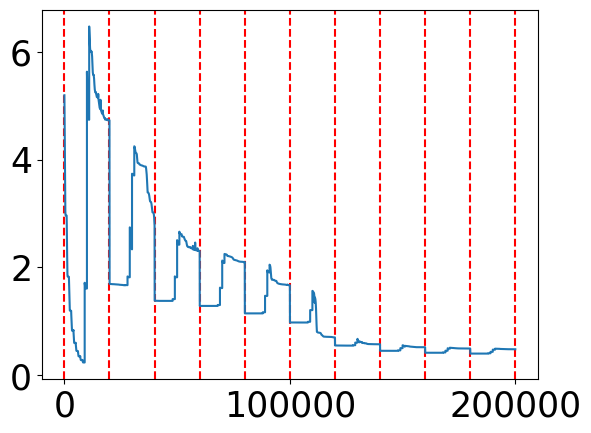

In [51]:
full = []
for l in losses_per_i:
    full = full + l
for i in range(I+1):
    plt.axvline(x = i * num_epochs * T, color = "red", linestyle = "--")
plt.plot(full)

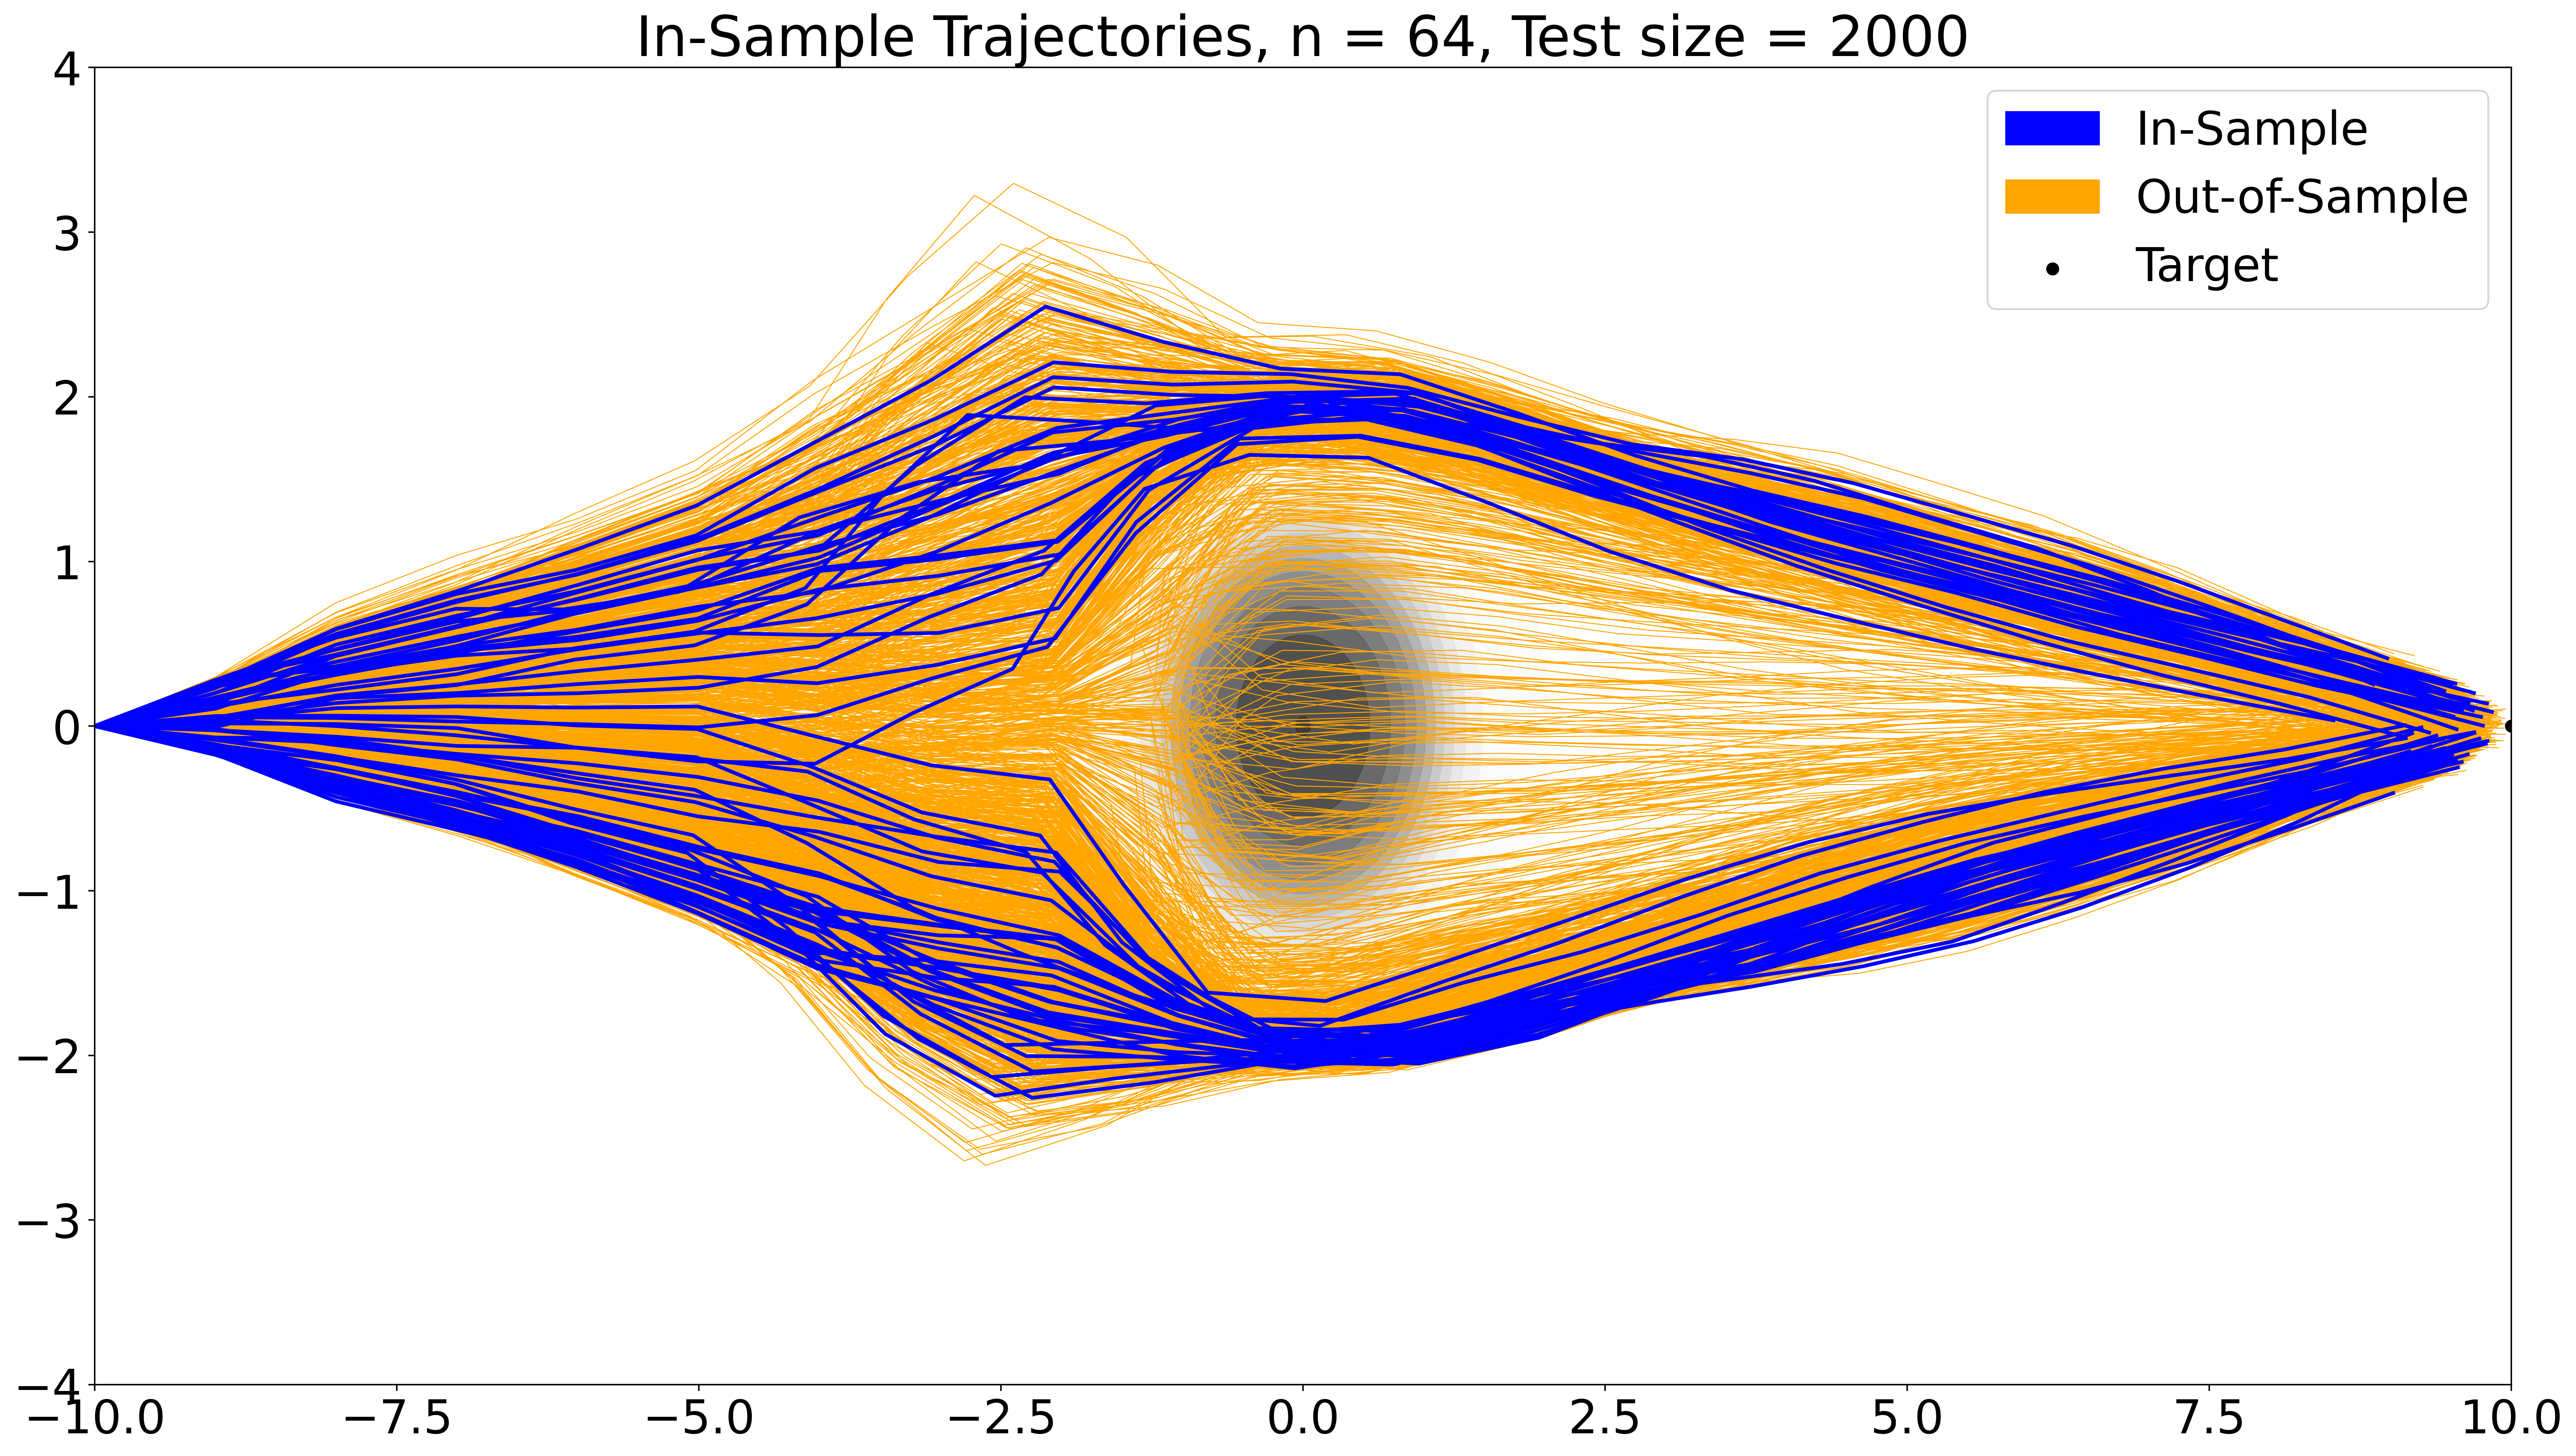

In [63]:
train_paths_erm = [initial_points]

# first for training paths
for t in range(T):
    angle = models_erm[t](torch.cat([train_paths_erm[-1]/torch.tensor([20, 10], device = device),
                                     training_winds[:, t].view(n, 1)], dim = 1))
    heading = torch.cat([torch.cos(angle), torch.sin(angle)], dim = 1)
    wind_vec = torch.cat([torch.zeros(n, 1, device = device), training_winds[:, t].view(n, 1)], dim = 1)
    new_p = train_paths_erm[-1] + vs* heading + wind_vec
    train_paths_erm.append(new_p)
train_paths_erm = torch.stack(train_paths_erm, dim = 1)

# generate test winds
test_size = 2000
test_winds = wind_process(T, theta, mu, wind_sigma, test_size, tau)

# generate test trajectories
test_paths_erm = [torch.zeros(test_size, 2, device = device) - torch.tensor([10, 0], device = device)]
for t in range(T):
    angle = models_erm[t](torch.cat([test_paths_erm[-1]/torch.tensor([20, 10], device = device),
                                     test_winds[:, t].view(test_size, 1)], dim = 1))
    heading = torch.cat([torch.cos(angle), torch.sin(angle)], dim = 1)
    wind_vec = torch.cat([torch.zeros(test_size, 1, device = device), test_winds[:, t].view(test_size, 1)], dim =1)
    new_p = test_paths_erm[-1] + vs * heading + wind_vec
    test_paths_erm.append(new_p)
test_paths_erm = torch.stack(test_paths_erm, dim = 1)

# plotting parameters
plt.rcParams.update({
    "axes.titlesize": 30,
    "axes.labelsize": 30,
    "xtick.labelsize": 25,
    "ytick.labelsize": 25,
    "legend.fontsize": 25,
    "font.size": 25
})

orange = mpatches.Patch(color="orange", label="Out-of-Sample")
blue = mpatches.Patch(color="blue", label="In-Sample")
fig, ax = plt.subplots(figsize=(19.2, 10.8), dpi=400,
                       constrained_layout = True)
ax.set_xlim(-10, 10)
ax.set_ylim(-4, 4)
grid_res = 300  # Resolution of the grid
x_vals = torch.linspace(-6, 6, grid_res)
y_vals = torch.linspace(-6, 6, grid_res)
X, Y = torch.meshgrid(x_vals, y_vals, indexing='xy')
Z = running_cost(X, Y, A=2, M=10)*100
Z[Z < 1.5] = float('nan')
ax.contourf(X.numpy(), Y.numpy(), Z.numpy(), levels=10, cmap='Greys', alpha=0.8)

for pth in range(test_size):
    plt.plot(test_paths_erm[pth, :, 0].detach().cpu(), test_paths_erm[pth, :, 1].detach().cpu(),
             color = "orange", linewidth = 0.5)
for pth in range(n):
    plt.plot(train_paths_erm[pth, :, 0].detach().cpu(), train_paths_erm[pth, :, 1].detach().cpu(),
             color = "blue", linewidth = 2)
    

ax.set_title(f"In-Sample Trajectories, n = {n}, Test size = {test_size}")
targ = ax.scatter(x=10, y=0, label="Target", color="black", zorder=1000)
ax.legend(handles=[blue, orange, targ])

plt.show()

plt.close()

In [64]:
full_cost_train_erm = (torch.sum(running_cost(train_paths_erm[:, :, 0], train_paths_erm[:, :, 1], A, M), dim = 1).detach().cpu().numpy()
                             + terminal_cost(train_paths_erm[:, -1, 0].view(n, 1),
                                             train_paths_erm[:, -1, 1].view(n, 1), L_x).detach().cpu().numpy()[:, 0])
full_cost_test_erm = (torch.sum(running_cost(test_paths_erm[:, :, 0], test_paths_erm[:, :, 1], A, M), dim = 1).detach().cpu().numpy()
                             + terminal_cost(test_paths_erm[:, -1, 0].view(test_size, 1),
                                             test_paths_erm[:, -1, 1].view(test_size, 1), L_x).detach().cpu().numpy()[:, 0])

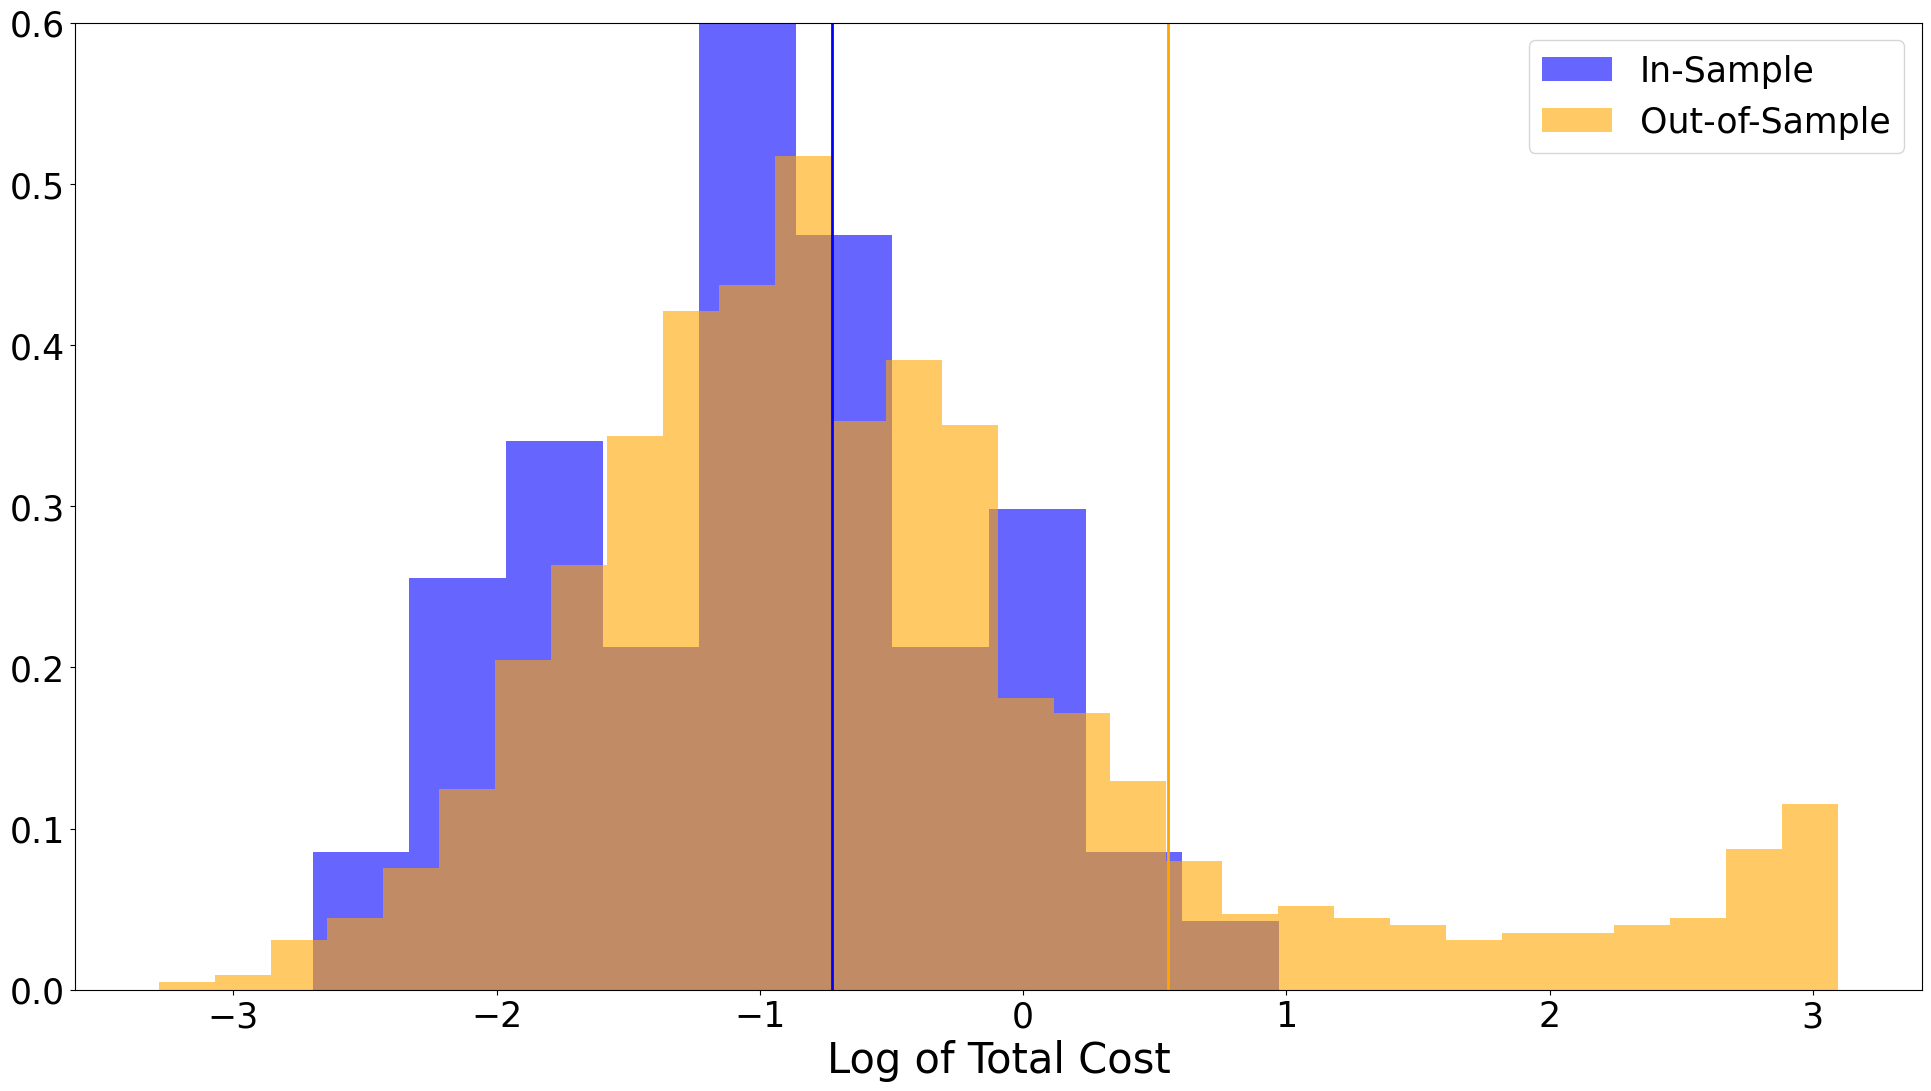

In [67]:
fig, ax = plt.subplots(figsize = (19.2, 10.8), constrained_layout = True)
ax.hist(np.log(full_cost_train_erm), bins = 10, density = True, alpha = 0.6, color = "blue", label = "In-Sample")
ax.hist(np.log(full_cost_test_erm), bins = 30, density = True, alpha = 0.6, color = "orange", label = "Out-of-Sample")
ax.set_ylim(0, 0.6)
tick_location_1 = np.log(np.mean(full_cost_test_erm))
ax.axvline(x=tick_location_1, color='orange', linewidth=2, linestyle = "-")
tick_location_2 = np.log(np.mean(full_cost_train_erm))
ax.axvline(x=tick_location_2, color='blue', linewidth=2)
ax.set_xlabel("Log of Total Cost")
# ax.set_title(f"ERM Costs, n = {n}, Test Size = {test_size}")
ax.legend()
plt.show()